In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal
import random

In [4]:
def gauss_2d(mu, sigma):
    x = random.gauss(mu, sigma)
    y = random.gauss(mu, sigma)
    return np.array([x,y])

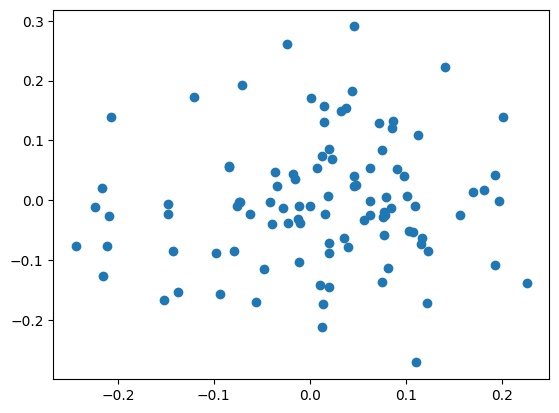

In [5]:

mu = 0
sigma = 0.1

nums = []
for i in range(100):
    nums.append(gauss_2d(mu, sigma))

coords = np.array(nums)

#print(coords)

#plt.figure(figsize=(10, 10))
plt.scatter(coords[:,0], coords[:,1])
plt.show()



Text(0, 0.5, 'Feature 2')

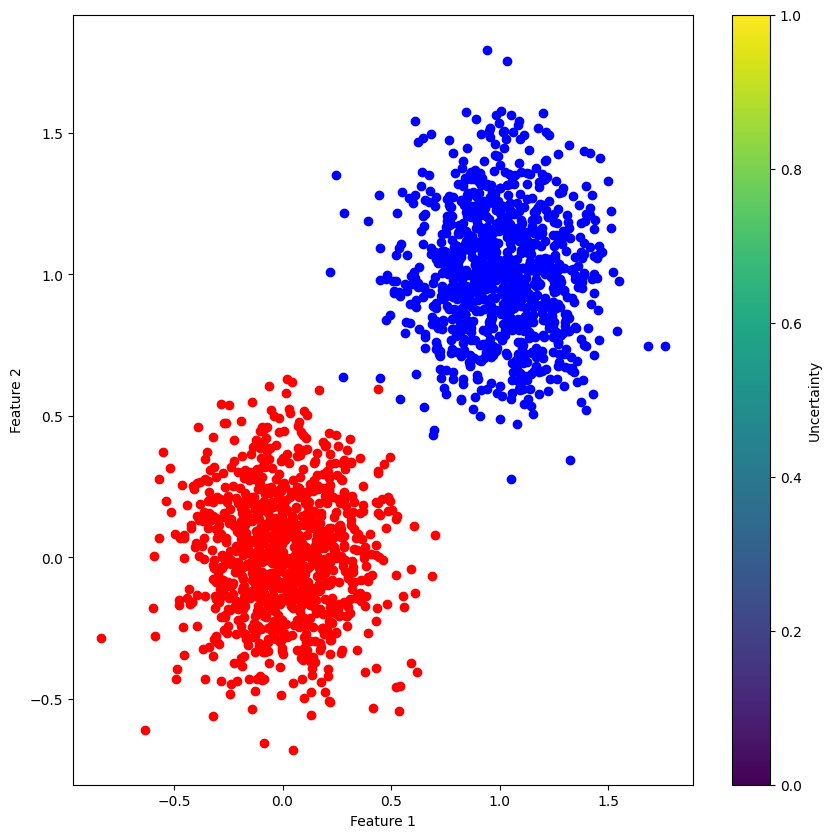

In [6]:
mu = [0,0]
mean = [1, 1]
sigma = [[0.05, 0], [0, 0.05]]


cluster1 = np.random.multivariate_normal(mu, sigma, 1000)
cluster2 = np.random.multivariate_normal(mean, sigma, 1000)


plt.figure(figsize=(10,10))


plt.scatter(cluster1[:,0], cluster1[:,1], color='r')
plt.scatter(cluster2[:,0], cluster2[:,1], color='b')
plt.colorbar(label="Uncertainty")


plt.xlabel('Feature 1')
plt.ylabel('Feature 2')



Text(0, 0.5, 'Feature 2')

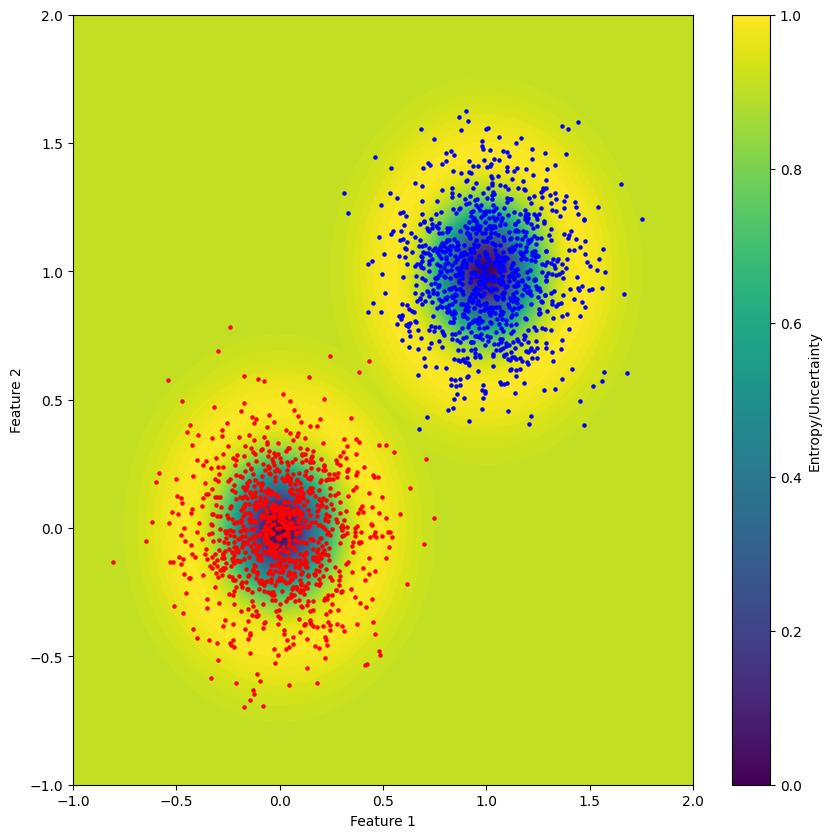

In [42]:
mu = [0,0]
mean = [1, 1]
sigma = [[0.05, 0], [0, 0.05]]


cluster1 = np.random.multivariate_normal(mu, sigma, 1000)
cluster2 = np.random.multivariate_normal(mean, sigma, 1000)

# 1. Create Grid
x_min = round(min(cluster1[:,0].min(), cluster2[:,0].min()))
x_max = round(max(cluster1[:,0].max(), cluster2[:,0].max()))

y_min = round(min(cluster1[:,1].min(), cluster2[:,1].min()))
y_max = round(max(cluster1[:,1].max(), cluster2[:,1].max()))

X = np.linspace(x_min, x_max, 1000)
Y = np.linspace(y_min, y_max, 1000)

X,Y = np.meshgrid(X, Y)
pos = np.dstack((X,Y))

# 2. Predict the uncertainty for the prediction of a normal gaussian distribution
model1 = multivariate_normal(mu, sigma)
model2 = multivariate_normal(mean, sigma)

# 3. Calculate the values at every coordinate on grid
Z1 = model1.pdf(pos)
Z2 = model2.pdf(pos)
Z = np.maximum(Z1, Z2)

entropy = -(Z*np.log(Z + 1e-9))
# 4. plot
plt.figure(figsize=(10,10))
plt.contourf(X, Y, entropy, levels=100, cmap='viridis', alpha=1)

# 5. Scatter random probabilities on top
plt.scatter(cluster1[:, 0], cluster1[:, 1], color='r', s=5, zorder = 10)
plt.scatter(cluster2[:, 0], cluster2[:, 1], color='b', s=5, zorder = 10)

plt.colorbar(label="Entropy/Uncertainty")
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
